## Testing Vectorizing Common Words in Unique Text Columns

Import after dimensionality reduction part of script

In [1]:
import os
os.getcwd()
#os.chdir("/Users/ellawileman/Documents/spring2025/dsci2/dsci2_final_project")

'/Users/ellawileman/Documents/spring2025/dsci2/dsci2_final_project'

In [2]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
#jobs = pd.read_csv("fake_job_postings.csv")
jobs = pd.read_csv("jobs_clean.csv")

For AI detector library:

In [3]:
!pip install transformers torch

* Need to run below cell the first time you use!! JK ended up being too computationally expensive to run the AI detector packages

In [4]:
'''
from transformers import AutoModelForSequenceClassification, AutoTokenizer

# Pre-load model and tokenizer
model = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased")
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

# Then create the pipeline manually
from transformers import TextClassificationPipeline
classifier = TextClassificationPipeline(model=model, tokenizer=tokenizer)

# Test inference
text = "This is an example of text."
output = classifier(text)
print(output)
'''


'\nfrom transformers import AutoModelForSequenceClassification, AutoTokenizer\n\n# Pre-load model and tokenizer\nmodel = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased")\ntokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")\n\n# Then create the pipeline manually\nfrom transformers import TextClassificationPipeline\nclassifier = TextClassificationPipeline(model=model, tokenizer=tokenizer)\n\n# Test inference\ntext = "This is an example of text."\noutput = classifier(text)\nprint(output)\n'

In [5]:
'''
from transformers import pipeline
# Load AI text detector pipeline
classifier = pipeline("text-classification", model="distilbert-base-uncased")
'''

'\nfrom transformers import pipeline\n# Load AI text detector pipeline\nclassifier = pipeline("text-classification", model="distilbert-base-uncased")\n'

In [6]:
jobs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 32 columns):
 #   Column                             Non-Null Count  Dtype 
---  ------                             --------------  ----- 
 0   department                         6327 non-null   object
 1   company_profile                    14572 non-null  object
 2   description                        17878 non-null  object
 3   requirements                       15182 non-null  object
 4   benefits                           10660 non-null  object
 5   telecommuting                      17880 non-null  int64 
 6   has_company_logo                   17880 non-null  int64 
 7   has_questions                      17880 non-null  int64 
 8   employment_type                    14409 non-null  object
 9   industry                           12977 non-null  object
 10  function                           11425 non-null  object
 11  fraudulent                         17880 non-null  int64 
 12  filt

1. vectorize "description" column and get top most frequent words as attributes
2. one-hot encode all other columns
3. stack them so we can train model on vectorized description AND other columns. We can repeat this for other high cardinality string type attributes.

In [7]:
jobs.nunique()

department                             143
company_profile                       1709
description                          14665
requirements                         11898
benefits                              6079
telecommuting                            2
has_company_logo                         2
has_questions                            2
employment_type                          5
industry                                80
function                                37
fraudulent                               2
filtered_industry                       50
Salary Given                             2
Grouped_Titles                       10909
Country                                 91
Region                                 325
City                                  2218
special_characters                       2
Bachelor_degree                          2
High school or equivalent                2
Unspecified degree requirement           2
Masters_degree                           2
Associates 

Further grouping job titles: methodology is open to some review -- nothing is final

In [8]:

from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
import string
default_stopwords = set(stopwords.words('english'))
# Assuming 'Grouped_Titles' is the column of interest
grouped_titles = jobs['Grouped_Titles'].fillna('')  # Replace NaN with empty strings
one_letter_words = set(string.ascii_lowercase)  # a, b, c, ..., z

# Combine the default stopwords with one-letter and two-letter words
extended_stopwords = default_stopwords.union(one_letter_words)
extended_stopwords = list(extended_stopwords)


# Preprocess the text
grouped_titles = grouped_titles.str.replace(r'\d+', '', regex=True)  # Remove numbers
grouped_titles = grouped_titles.str.replace(r'\byear olds?\b', '', regex=True, case=False)  # Remove "year olds"
grouped_titles = grouped_titles.str.replace(r'[^a-zA-Z\s]', '', regex=True)  # Remove non-alphabetic characters

# Adjustable thresholds
BIGRAM_THRESHOLD = 200  # Increase the number of top bigrams
UNIGRAM_THRESHOLD = 200  # Increase the number of top unigrams

# Step 1: Extract Bigrams
vectorizer_bigrams = CountVectorizer(ngram_range=(2, 2), stop_words=extended_stopwords, token_pattern=r'\b[a-zA-Z]+\b')
bigrams = vectorizer_bigrams.fit_transform(grouped_titles)

# Get the top bigrams
bigram_counts = bigrams.sum(axis=0)
bigram_frequencies = [(phrase, bigram_counts[0, idx]) for phrase, idx in vectorizer_bigrams.vocabulary_.items()]
bigram_frequencies = sorted(bigram_frequencies, key=lambda x: x[1], reverse=True)
top_bigrams = [phrase for phrase, count in bigram_frequencies[:BIGRAM_THRESHOLD]]

# Step 2: Extract Unigrams
vectorizer_unigrams = CountVectorizer(ngram_range=(1, 1), stop_words=extended_stopwords, token_pattern=r'\b[a-zA-Z]+\b')
unigrams = vectorizer_unigrams.fit_transform(grouped_titles)

# Get the top unigrams
unigram_counts = unigrams.sum(axis=0)
unigram_frequencies = [(word, unigram_counts[0, idx]) for word, idx in vectorizer_unigrams.vocabulary_.items()]
unigram_frequencies = sorted(unigram_frequencies, key=lambda x: x[1], reverse=True)
top_unigrams = [word for word, count in unigram_frequencies[:UNIGRAM_THRESHOLD]]

def map_to_bigram_or_unigram(title):
    # Check for specific bigrams first
    for bigram in top_bigrams:
        if bigram in title.lower():
            return bigram
    # Fallback to generic unigrams
    for unigram in top_unigrams:
        if unigram in title.lower():
            return unigram
    return "Other"


# Step 5: Apply the Mapping
jobs['Mapped_Title'] = grouped_titles.apply(lambda title: map_to_bigram_or_unigram(title))

# Analyze the distribution of groups
group_distribution = jobs['Mapped_Title'].value_counts()
print(group_distribution)

# Display the percentage of "Other"
percent_other = (group_distribution['Other'] / len(jobs)) * 100
print(f"Percentage of 'Other': {percent_other:.2f}%")

# don't want too many titles to be placed into other (loss of detail/info)

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/ellawileman/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Mapped_Title
manager               761
customer service      750
english teacher       721
Other                 696
engineer              628
                     ... 
rails                   1
beauty promotional      1
experience              1
insurance               1
entry clerk             1
Name: count, Length: 323, dtype: int64
Percentage of 'Other': 3.89%


In [9]:
# now want to group very low frequency titles into "Other"
MIN_FREQUENCY = 30  # Set the minimum frequency threshold

# Get the frequency of each label
label_frequencies = jobs['Mapped_Title'].value_counts()

# Identify labels below the threshold
low_frequency_labels = label_frequencies[label_frequencies < MIN_FREQUENCY].index

# Reassign low-frequency labels to "Other"
jobs['Mapped_Title'] = jobs['Mapped_Title'].apply(lambda x: "Other" if x in low_frequency_labels else x)

# Reanalyze the distribution of groups
group_distribution = jobs['Mapped_Title'].value_counts()

# Display the updated percentage of "Other"
percent_other = (group_distribution['Other'] / len(jobs)) * 100
print(f"Updated Percentage of 'Other': {percent_other:.2f}%")

display(group_distribution)

Updated Percentage of 'Other': 16.68%


Mapped_Title
Other                     2982
manager                    761
customer service           750
english teacher            721
engineer                   628
                          ... 
recruitment consultant      30
technical                   30
junior                      30
frontend engineer           30
title closer                30
Name: count, Length: 145, dtype: int64

Replicating logic to drop high-cardinality attributes (but plus description)

In [10]:
# X = jobs["description"]

# getting description, company profile, requirements attributes to tokenize
unique_values = jobs.nunique() 
selected_columns = unique_values[(unique_values <= 145) | (unique_values == 14665) | (unique_values == 1708) | (unique_values == 1709)| (unique_values == 11898) | (unique_values == 6079)].index

# Create a new DataFrame with selected columns
new_df = jobs[selected_columns]
new_df.columns

Index(['department', 'company_profile', 'description', 'requirements',
       'benefits', 'telecommuting', 'has_company_logo', 'has_questions',
       'employment_type', 'industry', 'function', 'fraudulent',
       'filtered_industry', 'Salary Given', 'Country', 'special_characters',
       'Bachelor_degree', 'High school or equivalent',
       'Unspecified degree requirement', 'Masters_degree', 'Associates degree',
       'Certification', 'Some College Coursework Completed', 'Mid-Senior',
       'Entry level', 'Associate', 'Not Application', 'Director', 'Internship',
       'Mapped_Title'],
      dtype='object')

Vectorize description column and company profile column using TfidfVectorizer (top 100 words)

In [11]:
'''
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords
import nltk
import string

# Replace NaN values in 'description' and 'company_profile' with empty strings
new_df['description'] = new_df['description'].fillna('')
new_df['company_profile'] = new_df['company_profile'].fillna('')
new_df['requirements'] = new_df['requirements'].fillna('')
new_df["benefits"] = new_df["benefits"].fillna('')

# Remove numbers directly from the text columns
new_df['description'] = new_df['description'].str.replace(r'\d+', '', regex=True)
new_df['company_profile'] = new_df['company_profile'].str.replace(r'\d+', '', regex=True)
new_df['requirements'] = new_df['requirements'].str.replace(r'\d+', '', regex=True)
new_df['benefits'] = new_df['benefits'].str.replace(r'\d+', '', regex=True)

# modifying stopwords list to excluse any one or two letter words
nltk.download('stopwords')
# Load default English stopwords
default_stopwords = set(stopwords.words('english'))
one_letter_words = set(string.ascii_lowercase)  # a, b, c, ..., z
two_letter_words = {a + b for a in string.ascii_lowercase for b in string.ascii_lowercase}  # aa, ab, ..., zz
# Combine default stopwords with one- and two-letter words
custom_stopwords = default_stopwords.union(one_letter_words).union(two_letter_words)
# Convert the stopwords set to a list (required by TfidfVectorizer)
custom_stopwords = list(custom_stopwords)

# Initialize TfidfVectorizer
vectorizer_description = TfidfVectorizer(ngram_range=(2, 5), max_features=100, stop_words=custom_stopwords)  # For description
vectorizer_company = TfidfVectorizer(ngram_range=(2, 5), max_features=100, stop_words=custom_stopwords)  # For company_profile
vectorizer_requirements = TfidfVectorizer(ngram_range=(2, 5), max_features=100, stop_words=custom_stopwords)  # For requirements
vectorizer_benefits = TfidfVectorizer(ngram_range=(2, 5), max_features=100, stop_words=custom_stopwords)  # For benefits

# Fit and transform the 'description' column
vectorizer_description.fit(new_df['description'])
new_df['description_vector'] = list(vectorizer_description.transform(new_df['description']).toarray())

# Fit and transform the 'company_profile' column
vectorizer_company.fit(new_df['company_profile'])
new_df['company_profile_vector'] = list(vectorizer_company.transform(new_df['company_profile']).toarray())

# Fit and transform the 'requirements' column
vectorizer_requirements.fit(new_df['requirements'])
new_df['requirements_vector'] = list(vectorizer_requirements.transform(new_df['requirements']).toarray())

# for benefits column
vectorizer_benefits.fit(new_df['benefits'])
new_df['benefits_vector'] = list(vectorizer_benefits.transform(new_df['benefits']).toarray())

# Drop the original text columns if no longer needed
new_df.drop(columns=['description', 'company_profile', 'requirements', 'benefits'], inplace=True)

# Print the selected features for both columns
print("Description Features:", vectorizer_description.get_feature_names_out())
print("Company Profile Features:", vectorizer_company.get_feature_names_out())
'''

'\nfrom sklearn.feature_extraction.text import TfidfVectorizer\nfrom nltk.corpus import stopwords\nimport nltk\nimport string\n\n# Replace NaN values in \'description\' and \'company_profile\' with empty strings\nnew_df[\'description\'] = new_df[\'description\'].fillna(\'\')\nnew_df[\'company_profile\'] = new_df[\'company_profile\'].fillna(\'\')\nnew_df[\'requirements\'] = new_df[\'requirements\'].fillna(\'\')\nnew_df["benefits"] = new_df["benefits"].fillna(\'\')\n\n# Remove numbers directly from the text columns\nnew_df[\'description\'] = new_df[\'description\'].str.replace(r\'\\d+\', \'\', regex=True)\nnew_df[\'company_profile\'] = new_df[\'company_profile\'].str.replace(r\'\\d+\', \'\', regex=True)\nnew_df[\'requirements\'] = new_df[\'requirements\'].str.replace(r\'\\d+\', \'\', regex=True)\nnew_df[\'benefits\'] = new_df[\'benefits\'].str.replace(r\'\\d+\', \'\', regex=True)\n\n# modifying stopwords list to excluse any one or two letter words\nnltk.download(\'stopwords\')\n# Load de

In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords
import nltk
import string

# Download NLTK stopwords
nltk.download('stopwords')

# Fill NaNs
text_cols = ['description', 'company_profile', 'requirements', 'benefits']
for col in text_cols:
    new_df[col] = new_df[col].fillna('')
    new_df[col] = new_df[col].str.replace(r'\d+', '', regex=True)

# Stopwords + short words filtering
default_stopwords = set(stopwords.words('english'))
one_letter_words = set(string.ascii_lowercase)
two_letter_words = {a + b for a in string.ascii_lowercase for b in string.ascii_lowercase}
custom_stopwords = list(default_stopwords.union(one_letter_words).union(two_letter_words))

def filter_ngrams(feature_names, tfidf_matrix, min_diff=0.2):
    """
    Filters out shorter n-grams if longer versions exist and are similarly frequent.
    Keeps shorter ones only if their overall importance is significantly higher.
    """
    import numpy as np
    from collections import defaultdict

    feature_scores = np.asarray(tfidf_matrix.mean(axis=0)).flatten()
    name_score_map = dict(zip(feature_names, feature_scores))
    to_remove = set()

    feature_set = set(feature_names)
    for short in feature_names:
        for long in feature_names:
            if short != long and short in long:
                if name_score_map[long] >= name_score_map[short] * (1 - min_diff):
                    to_remove.add(short)
    
    return [ngram for ngram in feature_names if ngram not in to_remove]
filtered_feature_map = {}

def vectorize_and_store(column, name):
    vectorizer = TfidfVectorizer(ngram_range=(2, 5), max_features=75, stop_words=custom_stopwords)
    tfidf_matrix = vectorizer.fit_transform(new_df[column])
    feature_names = vectorizer.get_feature_names_out()
    filtered_features = filter_ngrams(feature_names, tfidf_matrix)
    
    # Save the filtered features globally
    filtered_feature_map[name] = filtered_features

    # Keep only the selected columns
    selected_indices = [i for i, f in enumerate(feature_names) if f in filtered_features]
    reduced_matrix = tfidf_matrix[:, selected_indices]
    
    new_df[f'{name}_vector'] = list(reduced_matrix.toarray())
    print(f"{name.title()} Features:", filtered_features)

# Apply vectorization
vectorize_and_store('description', 'description')
vectorize_and_store('company_profile', 'company_profile')
vectorize_and_store('requirements', 'requirements')
vectorize_and_store('benefits', 'benefits')

# Drop original text columns
new_df.drop(columns=text_cols, inplace=True)


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/ellawileman/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
/var/folders/yz/btvl331d4g54624wdzgx_2hc0000gn/T/ipykernel_44946/3162276664.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df[col] = new_df[col].fillna('')
/var/folders/yz/btvl331d4g54624wdzgx_2hc0000gn/T/ipykernel_44946/3162276664.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df[col] = new_df[col].str.replace(r'\d+', '', regex=True)
/var/fo

Description Features: ['apply directly', 'asia usd monthly cost living', 'business development', 'cardsgabriel adkins url_edcbafbeedcdbdeccddacfdf url_dbdfcdbecfcabaeaacbfdeb', 'click apply', 'communication skills', 'customer service', 'day day', 'development team', 'fast growing', 'fast paced', 'feel free', 'front end', 'full time', 'get paid', 'high quality', 'ideal candidate', 'include limited', 'integral part', 'join team', 'kids get paid love travel', 'long term', 'new business', 'new york', 'part time', 'per week', 'play kids get paid love', 'products services', 'reimbursedexcellent student loans credit', 'responsibilities include', 'right candidate', 'sales team', 'social media', 'student loans credit cardsgabriel adkins', 'team members', 'usd monthly cost living housing', 'work closely', 'years experience']


/var/folders/yz/btvl331d4g54624wdzgx_2hc0000gn/T/ipykernel_44946/3162276664.py:56: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df[f'{name}_vector'] = list(reduced_matrix.toarray())


Company_Profile Features: ['around world', 'candidates engineering manufacturing highly technical', 'customer satisfaction', 'document communications', 'finding recruiting high quality candidates', 'full time', 'full time permanent positions many', 'get safe amp secure jobs', 'help teachers get safe amp', 'high quality', 'highly technical non technical jobs', 'increase productivity', 'interested finding recruiting high', 'large companies interested finding recruiting', 'long term', 'manufacturing highly technical non technical', 'medium large', 'medium large companies interested finding', 'new york', 'permanent positions many medium large', 'provide full time permanent', 'quality candidates engineering manufacturing', 'safe amp secure jobs abroad', 'solutions help', 'teachers get safe amp secure', 'valor services']
Requirements Features: ['ability work', 'able work', 'attention detail', 'bachelor degree', 'communication skills', 'computer science', 'customer service', 'degree required'

In [13]:
#print("Requirements Features:", vectorizer_requirements.get_feature_names_out())

In [14]:
#print("Benefits Features:", vectorizer_benefits.get_feature_names_out())

Data preparation: storing these tokens (most frequent words) with their respective column name

In [15]:
'''
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder

# Step 1: Decompose description_vector and company_profile_vector
description_features = vectorizer_description.get_feature_names_out()
company_profile_features = vectorizer_company.get_feature_names_out()
requirements_features = vectorizer_requirements.get_feature_names_out()
benefits_features = vectorizer_benefits.get_feature_names_out()

# Add suffixes to feature names
description_feature_names = [f"description_includes_{feature}" for feature in description_features]
company_profile_feature_names = [f"companyprof_includes_{feature}" for feature in company_profile_features]
requirements_feature_names = [f"requirements_includes_{feature}" for feature in requirements_features]
benefits_feature_names = [f"benefits_includes_{feature}" for feature in benefits_features]


# Convert description_vector and company_profile_vector to DataFrames
description_df = pd.DataFrame(
    np.vstack(new_df['description_vector'].values), 
    columns=description_feature_names
)
company_profile_df = pd.DataFrame(
    np.vstack(new_df['company_profile_vector'].values), 
    columns=company_profile_feature_names
)
requirements_df = pd.DataFrame(
    np.vstack(new_df['requirements_vector'].values), 
    columns=requirements_feature_names
)
benefits_df = pd.DataFrame(
    np.vstack(new_df['benefits_vector'].values), 
    columns=benefits_feature_names
)

# Concatenate the new DataFrames with the original DataFrame
new_df = pd.concat([new_df.reset_index(drop=True), description_df, company_profile_df, requirements_df, benefits_df], axis=1)

# Drop the original vector columns if no longer needed
new_df.drop(columns=['description_vector', 'company_profile_vector', 'requirements_vector', 'benefits_vector'], inplace=True)

# Step 2: One-Hot Encode Categorical Columns
encoder = OneHotEncoder(sparse_output=False)
categorical_columns = new_df.columns.difference(['fraudulent'] + description_feature_names + company_profile_feature_names + requirements_feature_names + benefits_feature_names)
categorical_features = encoder.fit_transform(new_df[categorical_columns])

categorical_feature_names = encoder.get_feature_names_out(categorical_columns)  # Feature names for categorical features
# Combine all feature names into a single list
all_feature_names = np.concatenate([description_feature_names, company_profile_feature_names, requirements_feature_names, benefits_feature_names, categorical_feature_names])

# Combine all features into a single matrix
X = np.hstack([description_df.values, company_profile_df.values, requirements_df.values, benefits_df.values, categorical_features])
y = new_df['fraudulent'].values  # Target variable

# Check the shape of the final feature matrix
print(f"Feature matrix shape: {X.shape}")
'''

'\nimport pandas as pd\nimport numpy as np\nfrom sklearn.feature_extraction.text import TfidfVectorizer\nfrom sklearn.preprocessing import OneHotEncoder\n\n# Step 1: Decompose description_vector and company_profile_vector\ndescription_features = vectorizer_description.get_feature_names_out()\ncompany_profile_features = vectorizer_company.get_feature_names_out()\nrequirements_features = vectorizer_requirements.get_feature_names_out()\nbenefits_features = vectorizer_benefits.get_feature_names_out()\n\n# Add suffixes to feature names\ndescription_feature_names = [f"description_includes_{feature}" for feature in description_features]\ncompany_profile_feature_names = [f"companyprof_includes_{feature}" for feature in company_profile_features]\nrequirements_feature_names = [f"requirements_includes_{feature}" for feature in requirements_features]\nbenefits_feature_names = [f"benefits_includes_{feature}" for feature in benefits_features]\n\n\n# Convert description_vector and company_profile_vec

In [16]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder

# Function to convert vectors to DataFrames with prefixed column names
def decompose_vector_column(df, column, prefix, feature_names):
    return pd.DataFrame(
        np.vstack(df[column].values),
        columns=[f"{prefix}_includes_{f}" for f in feature_names]
    )

# Decompose all vector columns using the stored filtered feature names
description_features = filtered_feature_map['description']
company_profile_features = filtered_feature_map['company_profile']
requirements_features = filtered_feature_map['requirements']
benefits_features = filtered_feature_map['benefits']

# Create feature DataFrames with prefixed names
description_df = decompose_vector_column(new_df, 'description_vector', 'description', description_features)
company_profile_df = decompose_vector_column(new_df, 'company_profile_vector', 'companyprof', company_profile_features)
requirements_df = decompose_vector_column(new_df, 'requirements_vector', 'requirements', requirements_features)
benefits_df = decompose_vector_column(new_df, 'benefits_vector', 'benefits', benefits_features)

# Concatenate the new feature columns with new_df
new_df = pd.concat(
    [new_df.reset_index(drop=True), description_df, company_profile_df, requirements_df, benefits_df], 
    axis=1
)

# Drop the original vector columns
new_df.drop(columns=['description_vector', 'company_profile_vector', 'requirements_vector', 'benefits_vector'], inplace=True)

# --- One-Hot Encoding for Remaining Categorical Columns ---
# Determine feature name lists
description_feature_names = description_df.columns.tolist()
company_profile_feature_names = company_profile_df.columns.tolist()
requirements_feature_names = requirements_df.columns.tolist()
benefits_feature_names = benefits_df.columns.tolist()

# Exclude known columns to isolate categorical columns
known_columns = ['fraudulent'] + description_feature_names + company_profile_feature_names + requirements_feature_names + benefits_feature_names
categorical_columns = new_df.columns.difference(known_columns)

# One-hot encode categorical columns
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
categorical_features = encoder.fit_transform(new_df[categorical_columns])
categorical_feature_names = encoder.get_feature_names_out(categorical_columns)

# Combine all features
all_feature_names = description_feature_names + company_profile_feature_names + requirements_feature_names + benefits_feature_names + categorical_feature_names.tolist()
X = np.hstack([
    description_df.values,
    company_profile_df.values,
    requirements_df.values,
    benefits_df.values,
    categorical_features
])
y = new_df['fraudulent'].values

print(f"Feature matrix shape: {X.shape}")


Feature matrix shape: (17880, 772)


In [17]:
len(categorical_features)

17880

In [18]:
new_df.columns

Index(['department', 'telecommuting', 'has_company_logo', 'has_questions',
       'employment_type', 'industry', 'function', 'fraudulent',
       'filtered_industry', 'Salary Given',
       ...
       'benefits_includes_short term', 'benefits_includes_sick leave',
       'benefits_includes_stock options', 'benefits_includes_term disability',
       'benefits_includes_vacation hours',
       'benefits_includes_vision insurance',
       'benefits_includes_without regard race',
       'benefits_includes_work environment', 'benefits_includes_work life',
       'benefits_includes_working environment'],
      dtype='object', length=207)

Extract description_vector as Numpy array, 
one-hot-encode categorical columns
combine encoded features with description_vector
train classifier on this

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import OneHotEncoder


One hot encode all other categorical columns:

In [20]:
'''
from sklearn.preprocessing import OneHotEncoder
import numpy as np

# Separate the target column
jobs = new_df
y = jobs['fraudulent'].values
# Select all columns except 'description_vector' and 'fraudulent'
# Step 2: One-Hot Encode Categorical Columns
encoder = OneHotEncoder(sparse_output=False)
categorical_columns = new_df.columns.difference(['fraudulent'] + description_feature_names + company_profile_feature_names)
categorical_features = encoder.fit_transform(new_df[categorical_columns])

# Step 3: Combine All Features
X = np.hstack([new_df[description_feature_names + company_profile_feature_names].values, categorical_features])

# Check the shape of the final feature matrix
print(X.shape)
'''

"\nfrom sklearn.preprocessing import OneHotEncoder\nimport numpy as np\n\n# Separate the target column\njobs = new_df\ny = jobs['fraudulent'].values\n# Select all columns except 'description_vector' and 'fraudulent'\n# Step 2: One-Hot Encode Categorical Columns\nencoder = OneHotEncoder(sparse_output=False)\ncategorical_columns = new_df.columns.difference(['fraudulent'] + description_feature_names + company_profile_feature_names)\ncategorical_features = encoder.fit_transform(new_df[categorical_columns])\n\n# Step 3: Combine All Features\nX = np.hstack([new_df[description_feature_names + company_profile_feature_names].values, categorical_features])\n\n# Check the shape of the final feature matrix\nprint(X.shape)\n"

In [21]:
'''
# One-hot encode the categorical columns
categorical_features = encoder.fit_transform(jobs[categorical_columns])

# Convert description_vector to a 2D NumPy array
description_vectors = np.vstack(jobs['description_vector'].values)
company_profile_vectors = np.vstack(jobs['company_profile_vector'].values)
X = np.hstack([description_vectors, company_profile_vectors, categorical_features])

print(X.shape)  # Check the shape of the combined feature matrix
X
'''

"\n# One-hot encode the categorical columns\ncategorical_features = encoder.fit_transform(jobs[categorical_columns])\n\n# Convert description_vector to a 2D NumPy array\ndescription_vectors = np.vstack(jobs['description_vector'].values)\ncompany_profile_vectors = np.vstack(jobs['company_profile_vector'].values)\nX = np.hstack([description_vectors, company_profile_vectors, categorical_features])\n\nprint(X.shape)  # Check the shape of the combined feature matrix\nX\n"

In [22]:
# After one-hot encoding:
len(X[0])
# there are 595 attributes!
# 395 attributes from one-hot encoding categorical predictors, and 100 from each of the text features

772

Random forest classifier

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a Random Forest model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)
feature_importances = model.feature_importances_

# Make predictions and evaluate the model
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print(classification_report(y_test, y_pred))

# Sort features by importance
sorted_indices = np.argsort(feature_importances)[::-1]  # Indices of features sorted by importance (descending)
sorted_features = [(all_feature_names[i], feature_importances[i]) for i in sorted_indices]

# Print the top 10 most important features
print("Top 10 Most Important Features:")
for feature, importance in sorted_features[:10]:
    print(f"{feature}: {importance:.4f}")

# feature importances sum up to 1

Accuracy: 0.9818
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      3395
           1       0.97      0.66      0.79       181

    accuracy                           0.98      3576
   macro avg       0.98      0.83      0.89      3576
weighted avg       0.98      0.98      0.98      3576

Top 10 Most Important Features:
has_company_logo_1: 0.0340
Mapped_Title_data entry: 0.0326
has_company_logo_0: 0.0289
industry_Oil & Energy: 0.0200
function_Administrative: 0.0162
filtered_industry_Oil & Energy: 0.0152
description_includes_per week: 0.0140
description_includes_part time: 0.0127
benefits_includes_work life: 0.0123
description_includes_get paid: 0.0111


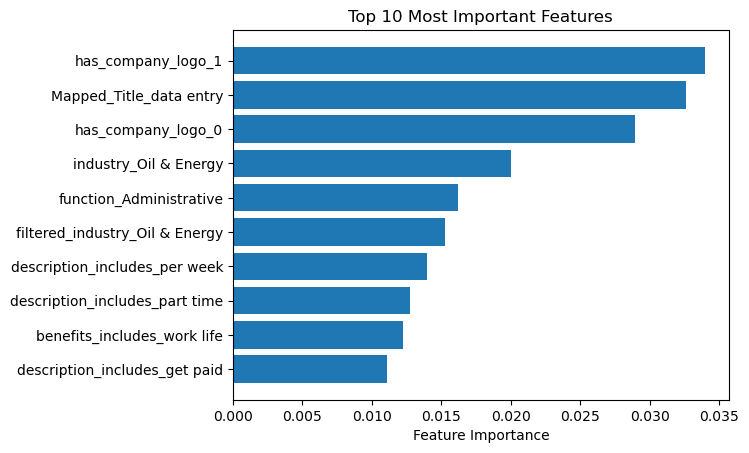

In [24]:
import matplotlib.pyplot as plt

# Plot feature importances
sorted_indices = np.argsort(feature_importances)[::-1]
top_features = sorted_indices[:10]  # Top 10 features
plt.barh(range(10), feature_importances[top_features])
plt.yticks(range(10), [all_feature_names[i] for i in top_features])
plt.xlabel("Feature Importance")
plt.title("Top 10 Most Important Features")
plt.gca().invert_yaxis()
plt.show()

# we expect that feature importance will be low! 

In [25]:
# Smote LR Model
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
smote = SMOTE(sampling_strategy='auto', random_state=42)  # auto balances the classes
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
model_smote = LogisticRegression(max_iter=1000, class_weight='balanced')
model_smote.fit(X_train_smote, y_train_smote)
y_pred_smote = model_smote.predict(X_test)
print(classification_report(y_test, y_pred_smote))

              precision    recall  f1-score   support

           0       0.99      0.94      0.97      3395
           1       0.45      0.85      0.59       181

    accuracy                           0.94      3576
   macro avg       0.72      0.89      0.78      3576
weighted avg       0.96      0.94      0.95      3576



Small improvement in metrics from version where all these variables are dropped. May see even better model performance with other variable-length string attributes.

We can repeat this methodology with other unique text columns like company description, requirements, benefits. Can also use digram, bigrams, etc. to get most common phrases

Maybe we can continue to group titles more by establishing some hierarchy, same with locations/region

Can we group these vectorized words at all? Try a different type of vectorizer that puts nearby words next to each other numerically (maybe an "includes" function would also be good for groupings rather than having to do all manual mappings)

### Start applying dimensionality reduction techniques

In [26]:
print(f"Currently there are {X_train_smote.shape[1]} columns")

Currently there are 772 columns


In [27]:
# from sklearn.feature_selection import RFECV

# selector = RFECV(estimator=model, step=1, cv=5, scoring='r2')
# selector.fit(X_train, y_train)

# print("Optimal number of features:", selector.n_features_)
# print("Selected features (boolean mask):", selector.support_)
# print("Feature ranking:", selector.ranking_)

### LDA

Projects the data onto a lower dimension space while preserving as much separation as possible. 

Starting with LDA because it is supervised while PCA is suited for unsupervised learning

In [28]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
lda = LinearDiscriminantAnalysis()
# transform with lda 
X_train_lda = lda.fit_transform(X_train, y_train)
X_test_lda = lda.transform(X_test)

# now Random Forest Classificiation
classifier = RandomForestClassifier(max_depth=2, random_state=0)
classifier.fit(X_train_lda, y_train)
y_pred_lda = classifier.predict(X_test_lda)

#confusion matrix 
print(classification_report(y_test, y_pred_lda))

print(X_train_lda.shape)
print(X_test.shape)


              precision    recall  f1-score   support

           0       0.98      0.99      0.98      3395
           1       0.72      0.60      0.65       181

    accuracy                           0.97      3576
   macro avg       0.85      0.79      0.82      3576
weighted avg       0.97      0.97      0.97      3576

(14304, 1)
(3576, 772)


Maybe a slight improvement because we have struck a pretty good balance between recall and precision for target = 1, but we have achieved higher results for other Random Forest models (precision was 98 and recall 64). 

#  Applying K Best for Dimensionality Reduction on the Vectorized Columns

### The columns that we are applying the transformation to: 

- Description
- Company profile
- Requirements
- Benefits

#### Description - with 38 columns 

In [29]:
description_df.shape

(17880, 38)

In [30]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
from sklearn.metrics import roc_auc_score

#### Creating a dataframe with just the exploded Description Column 

In [31]:
print(new_df.shape)

description_df['fraudulent'] = new_df['fraudulent']

X = description_df.drop(columns="fraudulent")
y = description_df["fraudulent"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


(17880, 207)


Skipping step one of removing highly correlated variables - can do that just not sure if we need?

##### Selecting K Best for description 

(17880, 38)
(17880,)


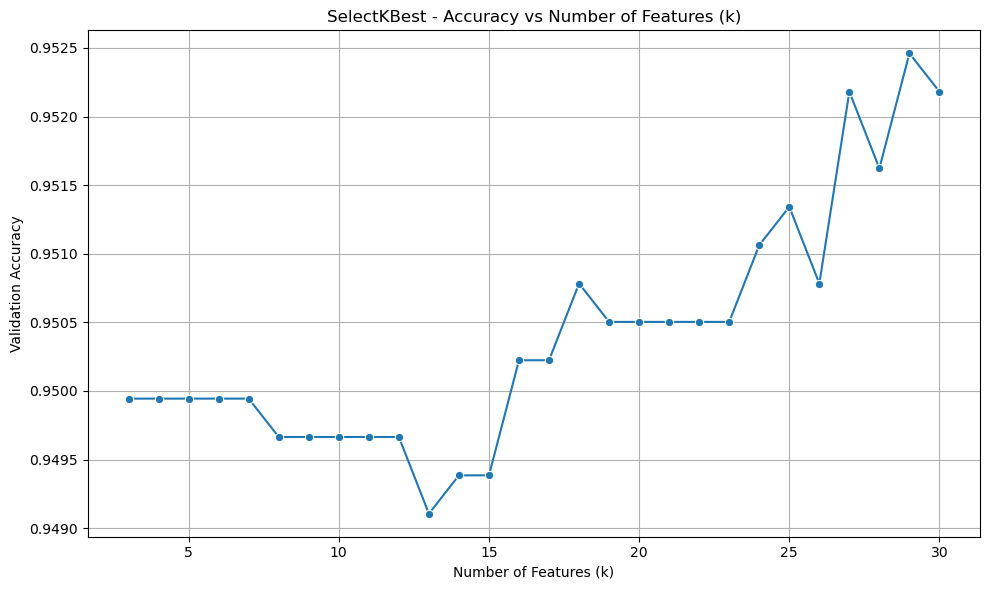

In [32]:
# K - best selection

results = []

print(X.shape)
print(y.shape)

description_feature_names = X_train.columns

max_k = min(30, len(description_feature_names))

for k in range(3, max_k + 1):
    selector = SelectKBest(f_classif, k=k)
    selector.fit(X_train, y_train)
    selected_cols = description_feature_names[selector.get_support()]

    X_train_desc_k = X_train[selected_cols]
    X_test_desc_k = X_test[selected_cols]

    # fitting random forest model for assessment 

    # these models are just the subset of data so might not be great at generalizing to the rest of the data
    # hopefully since RF is a simple model it will still give a good indication of the important variables 
    
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train_desc_k, y_train)

    y_pred = model.predict(X_test_desc_k)
    acc = accuracy_score(y_test, y_pred)
    
    results.append((k, acc))



# Plot accuracy vs. k
results_df = pd.DataFrame(results, columns=["k", "Validation Accuracy"])
plt.figure(figsize=(10,6))
sns.lineplot(x="k", y="Validation Accuracy", data=results_df, marker="o")
plt.title("SelectKBest - Accuracy vs Number of Features (k)")
plt.xlabel("Number of Features (k)")
plt.ylabel("Validation Accuracy")
plt.grid(True)
plt.tight_layout()
plt.show()



#### Extracting the most important features from Description

In [33]:
# Selecting the best Features 
k = 18
selector = SelectKBest(f_classif, k=k)
selector.fit(X_train, y_train)

selected_mask = selector.get_support()
selected_cols = description_feature_names[selected_mask]

# top features extracted 
X_train_k = X_train[selected_cols]
X_test_k = X_test[selected_cols]

X_train_k.columns



description_selected_cols = selected_cols




#### Creating a dataframe with K best columns

In [34]:
# getting their ranking by scores
all_scores = selector.scores_

selected_scores = all_scores[selected_mask]

# X_train_k.columns

# creating a dataframe with the top selected columns and their scores 

sorted_Scores = pd.DataFrame({
    'Feature': selected_cols,
    'Score': selected_scores
}).sort_values(by = "Score", ascending=False)

print(sorted_Scores)

                                              Feature       Score
11                     description_includes_part time  122.049585
7                       description_includes_get paid   89.685768
12                      description_includes_per week   71.354220
15                  description_includes_social media   29.483447
0   description_includes_asia usd monthly cost living   26.102548
17  description_includes_usd monthly cost living h...   25.322310
14  description_includes_reimbursedexcellent stude...   25.035140
8                  description_includes_integral part   24.931032
13       description_includes_play kids get paid love   24.761853
9      description_includes_kids get paid love travel   24.761853
1   description_includes_cardsgabriel adkins url_e...   24.347315
16  description_includes_student loans credit card...   24.347315
4                   description_includes_fast growing   24.058200
10                     description_includes_long term   23.177946
5         

/var/folders/yz/btvl331d4g54624wdzgx_2hc0000gn/T/ipykernel_44946/2678107507.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Normalized_Scores', y='shorter_names', data=sorted_Scores, palette='mako')


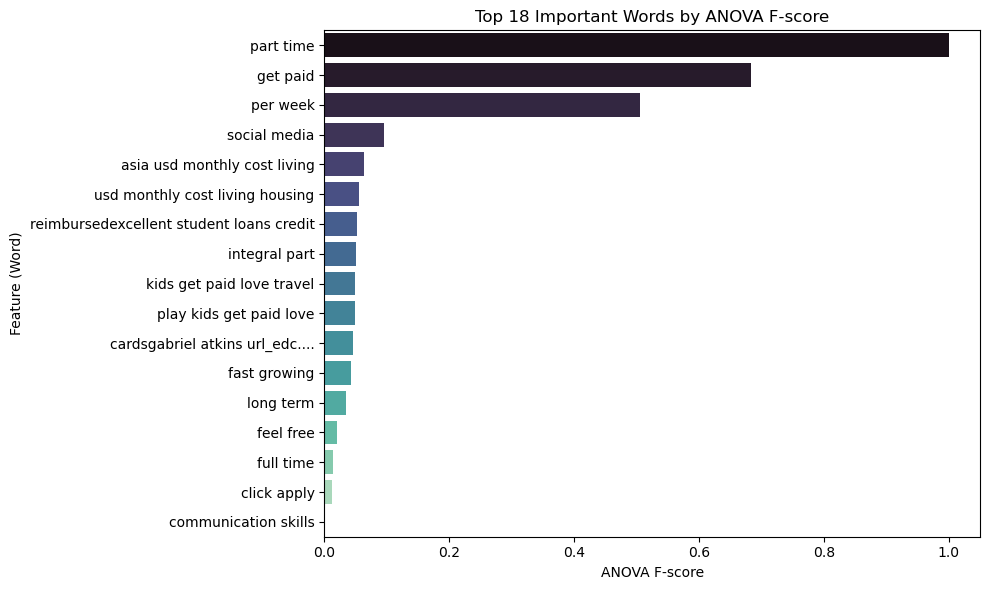

In [35]:
# trimming the feature name for clean visualization


sorted_Scores['shorter_names'] = sorted_Scores['Feature'].str.replace("description_includes_", "", regex= False)

# trimming the long url 

if sorted_Scores['shorter_names'].str.contains("cardsgabriel").any():
    sorted_Scores['shorter_names'] = sorted_Scores['shorter_names'].apply(
        lambda x: 'cardsgabriel atkins url_edc....' if 'cardsgabriel' in x else x
    )

sorted_Scores = sorted_Scores.sort_values(by = 'Score', ascending=False)

# Normalizing the anova score for better comparison 

scaler = MinMaxScaler()
sorted_Scores['Normalized_Scores'] = scaler.fit_transform(sorted_Scores[['Score']])


# barplot of the most important features 
plt.figure(figsize=(10,6))
sns.barplot(x='Normalized_Scores', y='shorter_names', data=sorted_Scores, palette='mako')
plt.title(f'Top {k} Important Words by ANOVA F-score')
plt.xlabel('ANOVA F-score')
plt.ylabel('Feature (Word)')
plt.tight_layout()
plt.show()

In [36]:
X_train_description = X_train_k 
print(X_train_description.shape)

(14304, 18)


#### Company Profile - with 26

In [37]:
print(company_profile_df.shape)


(17880, 26)


In [38]:
# subset data frame with company profile columns 

company_profile_df['fraudulent'] = new_df['fraudulent']

X = company_profile_df.drop(columns="fraudulent")
y = company_profile_df["fraudulent"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)




(17880, 26)
(17880,)


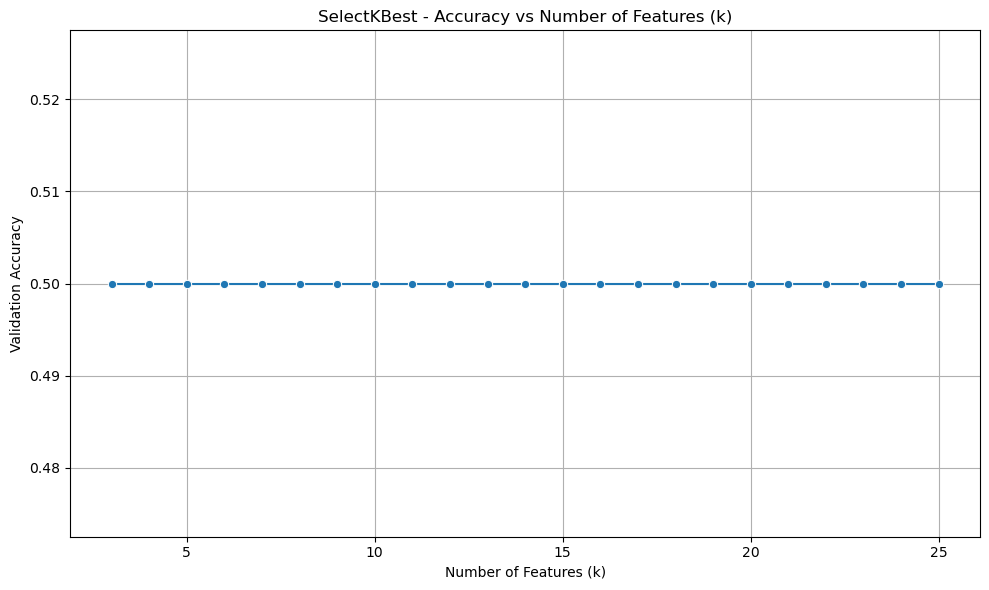

In [39]:
results = []

print(X.shape)
print(y.shape)

description_feature_names = X_train.columns

max_k = min(25, len(description_feature_names))

for k in range(3, max_k + 1):
    selector = SelectKBest(f_classif, k=k)
    selector.fit(X_train, y_train)
    selected_cols = description_feature_names[selector.get_support()]

    X_train_desc_k = X_train[selected_cols]
    X_test_desc_k = X_test[selected_cols]

    # fitting random forest model for assessment 

    model = LogisticRegression(max_iter=100)
    model.fit(X_train_desc_k, y_train)

    y_pred = model.predict(X_test_desc_k)
    auc = roc_auc_score(y_test, y_pred)
    
    results.append((k, auc))

# Plot accuracy vs. k
results_df = pd.DataFrame(results, columns=["k", "Validation Accuracy"])
plt.figure(figsize=(10,6))
sns.lineplot(x="k", y="Validation Accuracy", data=results_df, marker="o")
plt.title("SelectKBest - Accuracy vs Number of Features (k)")
plt.xlabel("Number of Features (k)")
plt.ylabel("Validation Accuracy")
plt.grid(True)
plt.tight_layout()
plt.show()

Not so sure what is going on there! Will look into more 

##### Lasso to try to reduce dimensionality 

In [40]:
logreg = LogisticRegression(penalty='l1', solver='liblinear', max_iter=1000)
logreg.fit(X_train, y_train)

coef = logreg.coef_[0]
features_names = X_train.columns

selected_mask = coef != 0
profile_selected_features = features_names[selected_mask]

profile_selected_features.shape

(13,)

In [41]:
selected_features_with_weights = list(zip(features_names[selected_mask], coef[selected_mask]))

# sorted by absolute value of the weight, descending (same effect as selector's feature importance above)
sorted_features = sorted(selected_features_with_weights, key=lambda x: abs(x[1]), reverse=True)

# Print them
for feature, weight in sorted_features:
    print(f"{feature}: {weight:.4f}")

companyprof_includes_safe amp secure jobs abroad: -5.4026
companyprof_includes_high quality: -5.2048
companyprof_includes_full time: -4.8410
companyprof_includes_teachers get safe amp secure: -4.4795
companyprof_includes_around world: -3.7620
companyprof_includes_long term: -2.9096
companyprof_includes_new york: -2.8799
companyprof_includes_customer satisfaction: -2.8596
companyprof_includes_medium large: -2.7766
companyprof_includes_solutions help: -2.4649
companyprof_includes_valor services: -2.2519
companyprof_includes_increase productivity: -1.1163
companyprof_includes_get safe amp secure jobs: -0.0023


### Requirements - with 55 columns 

In [42]:
requirements_df.shape

(17880, 55)

In [43]:
requirements_df['fraudulent'] = new_df['fraudulent']

X = requirements_df.drop(columns="fraudulent")
y = requirements_df["fraudulent"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

(17880, 55)
(17880,)


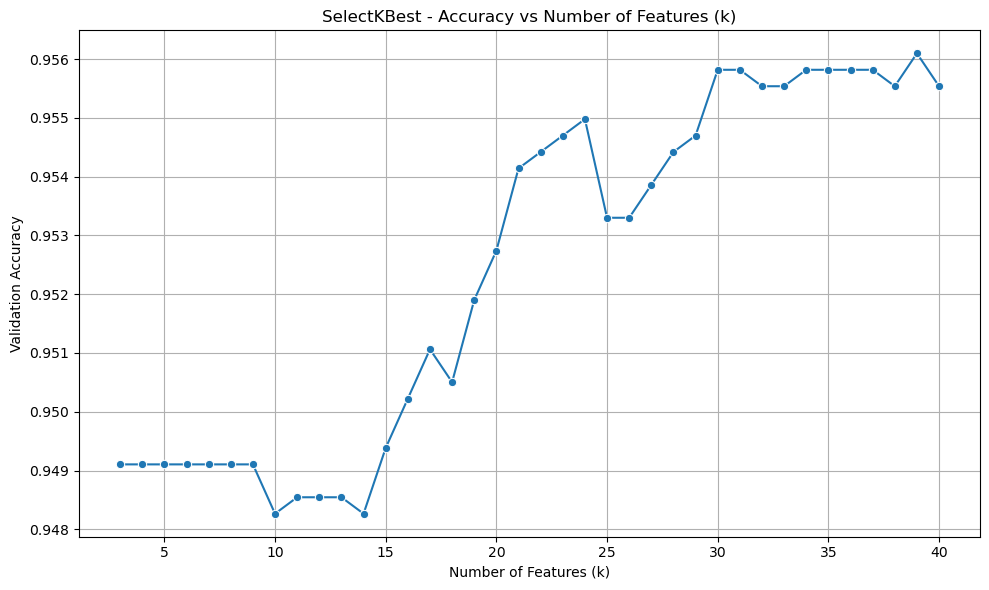

In [44]:
results = []

print(X.shape)
print(y.shape)

description_feature_names = X_train.columns

max_k = min(40, len(description_feature_names))

for k in range(3, max_k + 1):
    selector = SelectKBest(f_classif, k=k)
    selector.fit(X_train, y_train)
    selected_cols = description_feature_names[selector.get_support()]

    X_train_desc_k = X_train[selected_cols]
    X_test_desc_k = X_test[selected_cols]

    # fitting random forest model for assessment 

    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train_desc_k, y_train)

    y_pred = model.predict(X_test_desc_k)
    acc = accuracy_score(y_test, y_pred)
    
    results.append((k, acc))

# Plot accuracy vs. k
results_df = pd.DataFrame(results, columns=["k", "Validation Accuracy"])
plt.figure(figsize=(10,6))
sns.lineplot(x="k", y="Validation Accuracy", data=results_df, marker="o")
plt.title("SelectKBest - Accuracy vs Number of Features (k)")
plt.xlabel("Number of Features (k)")
plt.ylabel("Validation Accuracy")
plt.grid(True)
plt.tight_layout()
plt.show()

In [45]:
# Selecting 17 features
# 
# OR HONESLTY WE CAN EVEN DO LIKE 3 FEATURES SINCE ADDING 10+ FEATURES ONLY CHNAGES ACCURACY BY 10THS - lets discuss this!  
k = 17
selector = SelectKBest(f_classif, k=k)
selector.fit(X_train, y_train)

selected_mask = selector.get_support()
selected_cols = description_feature_names[selected_mask]

# top features extracted 
X_train_k = X_train[selected_cols]
X_test_k = X_test[selected_cols]

# getting their ranking by scores
all_scores = selector.scores_

selected_scores = all_scores[selected_mask]

# X_train_k.columns

# creating a dataframe with the top selected columns and their scores 

sorted_Scores = pd.DataFrame({
    'Feature': selected_cols,
    'Score': selected_scores
}).sort_values(by = "Score", ascending=False)

print(sorted_Scores)
print(sorted_Scores.shape)

req_selected_cols = selected_cols
# print(req_selected_cols)


                                              Feature       Score
3                   requirements_includes_high school  100.051452
4           requirements_includes_high school diploma   70.400965
11  requirements_includes_tefl tesol celta teachin...   29.345199
2   requirements_includes_degree required tefl tes...   28.758327
15  requirements_includes_university degree requir...   28.758327
7   requirements_includes_required tefl tesol celt...   28.758327
12  requirements_includes_tesol celta teaching exp...   27.626968
6              requirements_includes_passport holders   26.533393
14            requirements_includes_university degree   25.987119
16                   requirements_includes_word excel   25.566997
8                requirements_includes_school diploma   24.419979
5                      requirements_includes_html css   23.113780
10                 requirements_includes_social media   21.259237
1               requirements_includes_degree required   20.954400
0         

/var/folders/yz/btvl331d4g54624wdzgx_2hc0000gn/T/ipykernel_44946/3992728846.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Normalized_Scores', y='shorter_names', data=sorted_Scores, palette='mako')


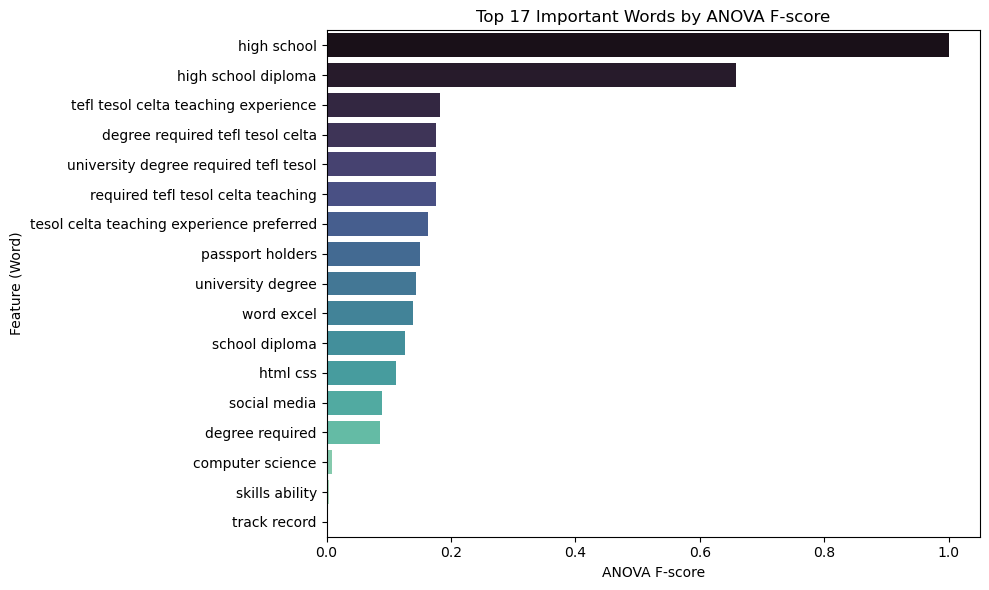

In [46]:
# trimming the feature name for clean visualization
sorted_Scores['shorter_names'] = sorted_Scores['Feature'].str.replace("requirements_includes_", "", regex= False)

sorted_Scores = sorted_Scores.sort_values(by = 'Score', ascending=False)

# normalizing the score 
scaler = MinMaxScaler()
sorted_Scores['Normalized_Scores'] = scaler.fit_transform(sorted_Scores[['Score']])


# barplot of the most important features 
plt.figure(figsize=(10,6))
sns.barplot(x='Normalized_Scores', y='shorter_names', data=sorted_Scores, palette='mako')
plt.title(f'Top {k} Important Words by ANOVA F-score')
plt.xlabel('ANOVA F-score')
plt.ylabel('Feature (Word)')
plt.tight_layout()
plt.show()



In [47]:
X_train_requirements = X_train_k 
print(X_train_requirements.shape)

(14304, 17)


### Benefits - with 62 columns

In [48]:
benefits_df.shape

(17880, 62)

In [49]:
benefits_df['fraudulent'] = new_df['fraudulent']

X = benefits_df.drop(columns="fraudulent")
y = benefits_df["fraudulent"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [50]:
print(y)
print(X)

0        0
1        0
2        0
3        0
4        0
        ..
17875    0
17876    0
17877    0
17878    0
17879    0
Name: fraudulent, Length: 17880, dtype: int64
       benefits_includes_base salary  benefits_includes_benefits include  \
0                                0.0                                 0.0   
1                                0.0                                 0.0   
2                                0.0                                 0.0   
3                                0.0                                 0.0   
4                                0.0                                 0.0   
...                              ...                                 ...   
17875                            0.0                                 0.0   
17876                            0.0                                 0.0   
17877                            0.0                                 0.0   
17878                            0.0                                 0.0 

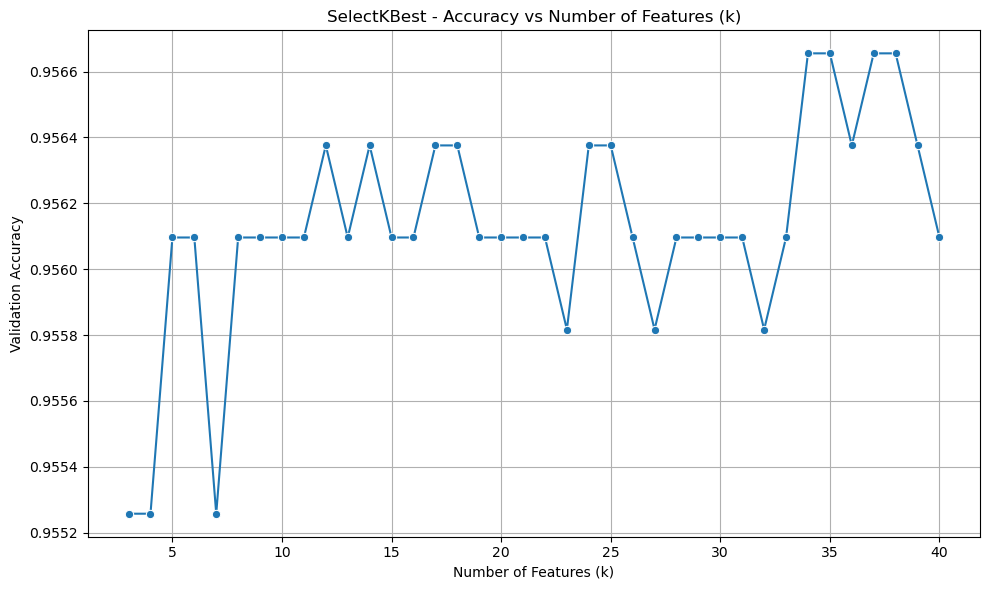

In [51]:
results = []

description_feature_names = X_train.columns

max_k = min(40, len(description_feature_names))

for k in range(3, max_k + 1):
    selector = SelectKBest(f_classif, k=k)
    selector.fit(X_train, y_train)
    selected_cols = description_feature_names[selector.get_support()]

    X_train_desc_k = X_train[selected_cols]
    X_test_desc_k = X_test[selected_cols]

    # fitting random forest model for assessment 

    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train_desc_k, y_train)

    y_pred = model.predict(X_test_desc_k)
    acc = accuracy_score(y_test, y_pred)
    
    results.append((k, acc))

# Plot accuracy vs. k
results_df = pd.DataFrame(results, columns=["k", "Validation Accuracy"])
plt.figure(figsize=(10,6))
sns.lineplot(x="k", y="Validation Accuracy", data=results_df, marker="o")
plt.title("SelectKBest - Accuracy vs Number of Features (k)")
plt.xlabel("Number of Features (k)")
plt.ylabel("Validation Accuracy")
plt.grid(True)
plt.tight_layout()
plt.show()

We can discuss the tradesoffs of the amount of features to select - clearly it is very violate based on the k, but also we are only looking at small changes in accuracy AND it is for an unsure model since it is not the entire dataset. 
- do we want more features instead of putting all our eggs into one basket with few features and hoping they apply well to the whole dataset model
- or is it really worth the potential information loss since we want dimensionality reduction/ interpretability 

In [52]:
k = 11
selector = SelectKBest(f_classif, k=k)
selector.fit(X_train, y_train)

selected_mask = selector.get_support()
selected_cols = description_feature_names[selected_mask]

# top features extracted 
X_train_k = X_train[selected_cols]
X_test_k = X_test[selected_cols]

# getting their ranking by scores
all_scores = selector.scores_

selected_scores = all_scores[selected_mask]

# X_train_k.columns

# creating a dataframe with the top selected columns and their scores 

sorted_Scores = pd.DataFrame({
    'Feature': selected_cols,
    'Score': selected_scores
}).sort_values(by = "Score", ascending=False)

benefits_selected_cols = selected_cols

print(sorted_Scores)

                                              Feature       Score
9                         benefits_includes_work life  234.552529
3                       benefits_includes_dental life  101.143937
1              benefits_includes_competitive benefits   83.739226
6                      benefits_includes_life balance   63.721495
10              benefits_includes_working environment   40.563981
8               benefits_includes_see job description   29.424971
2                benefits_includes_competitive salary   18.104295
7                         benefits_includes_paid time   15.927527
4                      benefits_includes_fast growing   15.824443
0   benefits_includes_benefits package full time e...   10.482743
5               benefits_includes_full time employees    9.703304


/var/folders/yz/btvl331d4g54624wdzgx_2hc0000gn/T/ipykernel_44946/3476996707.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Normalized_Scores', y='shorter_names', data=sorted_Scores, palette='mako')


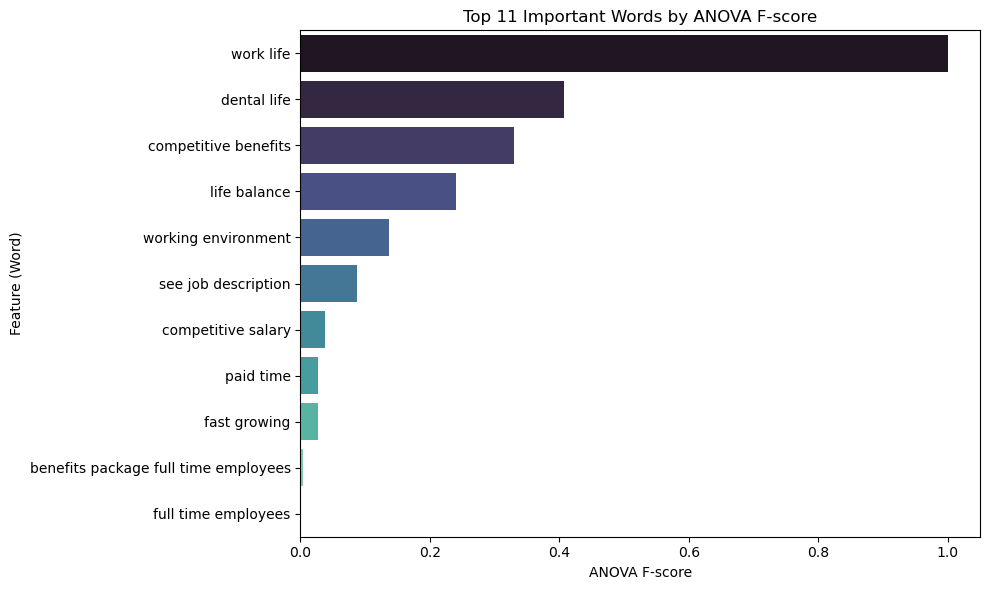

In [53]:
# trimming the feature name for clean visualization
sorted_Scores['shorter_names'] = sorted_Scores['Feature'].str.replace("benefits_includes_", "", regex= False)

sorted_Scores = sorted_Scores.sort_values(by = 'Score', ascending=False)

# normalizing score
scaler = MinMaxScaler()
sorted_Scores['Normalized_Scores'] = scaler.fit_transform(sorted_Scores[['Score']])

# barplot of the most important features 
plt.figure(figsize=(10,6))
sns.barplot(x='Normalized_Scores', y='shorter_names', data=sorted_Scores, palette='mako')
plt.title(f'Top {k} Important Words by ANOVA F-score')
plt.xlabel('ANOVA F-score')
plt.ylabel('Feature (Word)')
plt.tight_layout()
plt.show()

In [54]:
#X_train_benefits = X_train_k 
#print(X_train_benefits.shape)

## Concatenating the K-best columns back into the dataframe

In [55]:
print(new_df.shape)

(17880, 207)


In [56]:
dropped_cols = ['description', 'benefits', 'requirements', 'company_profile']

#for i in dropped_cols:
   # jobs = jobs.drop(i, axis = 1)

print(f'Dims before feature reduction: {new_df.shape}')

jobs_with_top_features = pd.concat([jobs, new_df[description_selected_cols]], axis=1)
jobs_with_top_features = pd.concat([jobs_with_top_features, new_df[req_selected_cols]], axis=1)
jobs_with_top_features = pd.concat([jobs_with_top_features, new_df[benefits_selected_cols]], axis=1)
jobs_with_top_features = pd.concat([jobs_with_top_features, new_df[profile_selected_features]], axis=1)


print(f'Dims after feature reduction: {jobs_with_top_features.shape}')


jobs_with_top_features

Dims before feature reduction: (17880, 207)
Dims after feature reduction: (17880, 92)


,department,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,industry,...,companyprof_includes_get safe amp secure jobs,companyprof_includes_high quality,companyprof_includes_increase productivity,companyprof_includes_long term,companyprof_includes_medium large,companyprof_includes_new york,companyprof_includes_safe amp secure jobs abroad,companyprof_includes_solutions help,companyprof_includes_teachers get safe amp secure,companyprof_includes_valor services
0,Marketing,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,NaN,...,0.0,0.000000,0.0,0.0,0.000000,1.0,0.0,0.0,0.0,0.0
1,other,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Marketing and Advertising,...,0.0,1.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
2,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,...,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,1.0
3,Sales,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Computer Software,...,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
4,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Hospital & Health Care,...,0.0,0.000000,0.0,1.0,0.000000,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17875,Sales,Vend is looking for some awesome new talent to...,Just in case this is the first time you’ve vis...,To ace this role you:Will eat comprehensive St...,What can you expect from us?We have an open cu...,0,1,1,Full-time,Computer Software,...,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
17876,Accounting,WebLinc is the e-commerce platform and service...,The Payroll Accountant will focus primarily on...,- B.A. or B.S. in Accounting- Desire to have f...,Health &amp; WellnessMedical planPrescription ...,0,1,1,Full-time,Internet,...,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
17877,NaN,We Provide Full Time Permanent Positions for m...,Experienced Project Cost Control Staff Enginee...,At least 12 years professional experience.Abil...,NaN,0,0,0,Full-time,NaN,...,0.0,0.137001,0.0,0.0,0.147939,0.0,0.0,0.0,0.0,0.0
17878,NaN,NaN,Nemsia Studios is looking for an experienced v...,1. Must be fluent in the latest versions of Co...,Competitive salary (compensation will be based...,0,0,1,Contract,Graphic Design,...,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0


In [57]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency


# Function to compute Chi-Squared statistic between feature and label
def chi_squared_statistic(feature, label):
    # Create a contingency table
    contingency_table = pd.crosstab(feature, label)
    
    # Compute the Chi-Squared statistic and p-value
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    
    return chi2

# Calculate Chi-Squared statistics for each feature with respect to the label
chi_squared_values = X.apply(lambda col: chi_squared_statistic(col, y))

# Sort the Chi-Squared values in descending order
chi_squared_values_sorted = chi_squared_values.sort_values(ascending=False)

# Show top N features with highest association to the label
top_n = 10
print("Top 10 features with highest Chi-squared statistic with the label:")
print(chi_squared_values_sorted.head(top_n))


Top 10 features with highest Chi-squared statistic with the label:
benefits_includes_work life                   1247.497498
benefits_includes_benefits package            1073.697884
benefits_includes_life balance                 892.767948
benefits_includes_paid time                    746.417468
benefits_includes_competitive benefits         695.764286
benefits_includes_compensation package         641.929915
benefits_includes_full benefits                622.157450
benefits_includes_competitive compensation     597.421459
benefits_includes_health dental                580.732490
benefits_includes_working environment          558.898938
dtype: float64


### Fitting Random Forest to test effectiveness of dimensionality reduction

In [58]:
X = jobs_with_top_features.drop(columns="fraudulent")
y = jobs_with_top_features["fraudulent"].values.ravel()


In [59]:
print(X.dtypes)


department                                            object
company_profile                                       object
description                                           object
requirements                                          object
benefits                                              object
                                                      ...   
companyprof_includes_new york                        float64
companyprof_includes_safe amp secure jobs abroad     float64
companyprof_includes_solutions help                  float64
companyprof_includes_teachers get safe amp secure    float64
companyprof_includes_valor services                  float64
Length: 91, dtype: object


In [60]:
X = pd.get_dummies(X, drop_first=True)

In [61]:

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


### Random Forest

In [62]:

# Train a Random Forest model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)
feature_importances = model.feature_importances_

# Make predictions and evaluate the model
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print(classification_report(y_test, y_pred))

Accuracy: 0.9793
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      3395
           1       1.00      0.59      0.74       181

    accuracy                           0.98      3576
   macro avg       0.99      0.80      0.87      3576
weighted avg       0.98      0.98      0.98      3576



### SVM (Reduced Model)

In [63]:
'''
from sklearn.svm import SVC
svm = SVC(kernel='linear')  # Linear kernel is good choice for text classification
svm.fit(X_train, y_train)

# Make predictions on the test set
y_pred = svm.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print(classification_report(y_test, y_pred))
'''


'\nfrom sklearn.svm import SVC\nsvm = SVC(kernel=\'linear\')  # Linear kernel is good choice for text classification\nsvm.fit(X_train, y_train)\n\n# Make predictions on the test set\ny_pred = svm.predict(X_test)\naccuracy = accuracy_score(y_test, y_pred)\nprint(f"Accuracy: {accuracy:.4f}")\nprint(classification_report(y_test, y_pred))\n'

### Multinomial NB

In [64]:
from sklearn.naive_bayes import MultinomialNB
nb = MultinomialNB()
nb.fit(X_train, y_train)
y_pred = nb.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print(classification_report(y_test, y_pred))

Accuracy: 0.9670
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      3395
           1       0.94      0.37      0.53       181

    accuracy                           0.97      3576
   macro avg       0.96      0.68      0.76      3576
weighted avg       0.97      0.97      0.96      3576



In [66]:
'''
from lightgbm import LGBMClassifier
lgb = LGBMClassifier()
lgb.fit(X_train, y_train)
y_pred = lgb.predict(X_test)
'''

'\nfrom lightgbm import LGBMClassifier\nlgb = LGBMClassifier()\nlgb.fit(X_train, y_train)\ny_pred = lgb.predict(X_test)\n'

In [69]:
from sklearn.linear_model import SGDClassifier
sgd = SGDClassifier(loss='hinge')  # 'hinge' for SVM-like behavior
sgd.fit(X_train, y_train)
y_pred = sgd.predict(X_test)


In [70]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print(classification_report(y_test, y_pred))

Accuracy: 0.9821
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3395
           1       0.89      0.74      0.81       181

    accuracy                           0.98      3576
   macro avg       0.94      0.87      0.90      3576
weighted avg       0.98      0.98      0.98      3576



## Looking at feature importances again

In [ ]:

# Sort features by importance
sorted_indices = np.argsort(feature_importances)[::-1]  # Indices of features sorted by importance (descending)
sorted_features = [(X.columns[i], feature_importances[i]) for i in sorted_indices]

# Print the top 10 most important features
print("Top 10 Most Important Features:")
for feature, importance in sorted_features[:10]:
    print(f"{feature}: {importance:.4f}")

# feature importances sum up to 1

Top 10 Most Important Features:
has_company_logo: 0.0231
Mapped_Title_data entry: 0.0146
filtered_industry_Oil & Energy: 0.0095
company_profile_Aptitude Staffing Solutions has redesigned the recruiting wheel. Our innovative new platform cuts the recruiting time in half, yields scientifically-proven results and clients and candidates enjoy a pleasant experience through advanced, simple to use technology and a tenured, industry-experienced recruiting team. Join us in a fresh new experience of leveraging your career...the way it should be! All represented candidates enjoy the following perks:Expert negotiations, maximizing total compensation package Signing bonus by Aptitude Staffing in addition to client signing bonus (if applicable)1 Year access to AnyPerkRelocation Services for out of town candidatesContinued education in your area of profession, seminars, workshops and other skill development events Contract employees receive quarterly bonuses for the duration of their project Direct-

### XGBoost 

In [ ]:
import xgboost as xgb

In [ ]:
X.columns = X.columns.str.replace(r'[\[\]<>]', '_', regex=True)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


model = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss',  # avoids warning
    random_state=42
)

# Train the model
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print(classification_report(y_test, y_pred))

/Users/ellawileman/anaconda3/lib/python3.11/site-packages/xgboost/training.py:183: UserWarning: [00:37:53] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.9785
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      3395
           1       0.96      0.60      0.74       181

    accuracy                           0.98      3576
   macro avg       0.97      0.80      0.86      3576
weighted avg       0.98      0.98      0.98      3576



In [71]:
X.columns

Index(['telecommuting', 'has_company_logo', 'has_questions', 'Salary Given',
       'special_characters', 'Bachelor_degree', 'High school or equivalent',
       'Unspecified degree requirement', 'Masters_degree', 'Associates degree',
       ...
       'Mapped_Title_title closer', 'Mapped_Title_title insurance',
       'Mapped_Title_ui', 'Mapped_Title_ui designer',
       'Mapped_Title_ux designer', 'Mapped_Title_visual designer',
       'Mapped_Title_web', 'Mapped_Title_web designer',
       'Mapped_Title_web developer', 'Mapped_Title_writer'],
      dtype='object', length=48417)

Notes: can also compute length and word counts of unique text fields as an attribute
Can store sentiment of these columns too and see if more useful than the actual tokens.

Otherwise I say we get to comparing models (base learners) and maybe making a meta learner


# Comparing Base Learners

Use feature importance (permutation importance from Sklearn) to see if our models are focusing on the same features! We want them to be really good at learning different features in order to combine in an ensemble that isn’t redundant! How can we measure correlation between models (if they are making same errors?) Prioritize model diversity over accuracy in choosing models for ensemble!
* Compute pearson coefficient (would compare how similar each model’s confidence in their predictions are - not just the label itself for each instance)
predict_proba(X)[:, 1] for each model and get pearson coeff of this
* Compute disagreement rate (between class labels of models -> low disagreement: redundant models)
disagreement = np.mean(preds_model1 != preds_model2) 
* Compute Cohen’s Kappa statistic (minimize for model pairs)
Adjusts for agreement by chance and class imbalance (note we have perfectly balanced classes) 
* Directly compare confusion matrixes
* Q statistic (measures correlation of correct predictions)
* Double fault measure (when are models both wrong?)
